## Building a Tweet Sentiment Analysis Models using LSTM Models


In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from nltk.corpus import stopwords
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\sayantghosh\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

## Creating a Dummy Dataset

In [101]:
train_df = pd.read_csv('sentiment_dataset/train.csv').sample(n=2000, random_state=42)
test_df = pd.read_csv('sentiment_dataset/test.csv').sample(n=200, random_state=42)
valid_df = pd.read_csv('sentiment_dataset/valid.csv').sample(n=200, random_state=42)

train_df.rename(columns={'text': 'tweet'}, inplace=True)
test_df.rename(columns={'text': 'tweet'}, inplace=True)
valid_df.rename(columns={'text': 'tweet'}, inplace=True)

train_df.head()

,tweet,label
32823,The central theme in this movie seems to be co...,0
16298,"An excellent example of ""cowboy noir"", as it's...",1
28505,The ending made my heart jump up into my throa...,0
6689,Only the chosen ones will appreciate the quali...,1
26893,"This is a really funny film, especially the se...",1


In [102]:
train_df.shape, test_df.shape, valid_df.shape

((2000, 2), (200, 2), (200, 2))

In [103]:
valid_df.head()

,tweet,label
1501,Lost has been one of the most mesmerizing and ...,1
2586,Born Again the Limerick: <br /><br />If a man ...,1
2653,This is a great horror movie. Great Plot. And ...,1
1055,"""Dead Man Walking"" is one of the most powerful...",1
705,"""Diary of Sex Addict"" is a pathetic attempt at...",0


In [104]:
# TF-IDF Vectorization
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.stem import PorterStemmer
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score, classification_report

stemmer = PorterStemmer()

def clean_process_text_with_stemming(tweet):
    tweet = tweet.lower()
    tweet = ''.join(char for char in tweet if char.isalnum() or char.isspace())
    tweet = ' '.join(tweet.split())
    stop_words = set(stopwords.words('english'))
    tweet = ' '.join(word for word in tweet.split() if word not in stop_words)
    tweet = ' '.join(stemmer.stem(word) for word in tweet.split())
    return tweet

In [105]:
train_df['tweet'] = train_df['tweet'].apply(clean_process_text_with_stemming)
valid_df['tweet'] = valid_df['tweet'].apply(clean_process_text_with_stemming)
test_df['tweet'] = test_df['tweet'].apply(clean_process_text_with_stemming)

train_df.head()

,tweet,label
32823,central theme movi seem confus relationship se...,0
16298,excel exampl cowboy noir call unemploy michael...,1
28505,end made heart jump throat proceed leav movi t...,0
6689,chosen one appreci qualiti stori charact desig...,1
26893,realli funni film especi second third fourth t...,1


## Exploratory Data Analysis

Text(0.5, 1.0, 'Distribution of Labels')

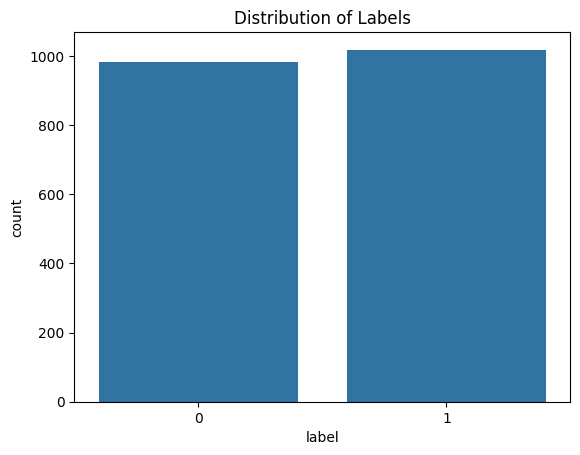

In [106]:
## Checking the distribution of labels
sns.countplot(x='label', data=train_df)
plt.title('Distribution of Labels')

<Axes: xlabel='length', ylabel='Count'>

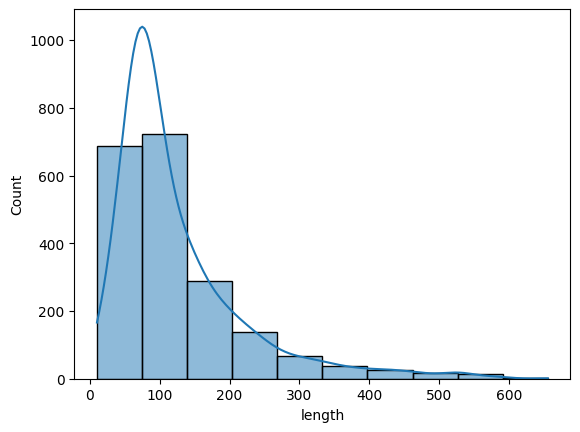

In [107]:
## Analyzing the length of the tweets
train_df['length'] = train_df['tweet'].apply(lambda x: len(x.split()))
sns.histplot(train_df['length'], bins=10, kde=True)

<Axes: xlabel='length', ylabel='Count'>

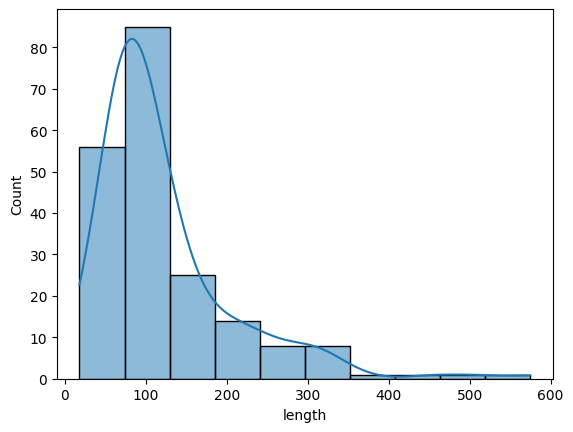

In [108]:
## Validation Dataset length distribution
valid_df['length'] = valid_df['tweet'].apply(lambda x: len(x.split())) 
sns.histplot(valid_df['length'], bins=10, kde=True)

---

## SGD Classifier Model

In [109]:
# Apply stemming to the tweets
df_stemmed = train_df.copy()
df_stemmed['tweet'] = df_stemmed['tweet'].apply(clean_process_text_with_stemming)
df_stemmed.head()

vectorizer = TfidfVectorizer(max_features=1000)
X_train_tfidf = vectorizer.fit_transform(df_stemmed['tweet'])
y_train_tfidf = df_stemmed['label']

# Prepare validation set with stemming
df_valid_stemmed = valid_df.copy()
df_valid_stemmed['tweet'] = df_valid_stemmed['tweet'].apply(clean_process_text_with_stemming)
X_valid_tfidf = vectorizer.transform(df_valid_stemmed['tweet'])
y_valid_tfidf = df_valid_stemmed['label']

In [110]:
clf = SGDClassifier(loss='hinge', penalty='l2', 
                    alpha=0.0001, l1_ratio=0.15, 
                    fit_intercept=True, max_iter=1000, 
                    tol=0.001, shuffle=True, verbose=0, 
                    epsilon=0.1, n_jobs=None, 
                    random_state=None, learning_rate='optimal', 
                    eta0=0.0, power_t=0.5, early_stopping=False, 
                    validation_fraction=0.1, n_iter_no_change=5, 
                    class_weight=None, warm_start=False, average=False)

clf.fit(X_train_tfidf, y_train_tfidf)
y_pred_valid = clf.predict(X_valid_tfidf)

print('SGDClassifier Validation Accuracy:', accuracy_score(y_valid_tfidf, y_pred_valid))
print(classification_report(y_valid_tfidf, y_pred_valid))

SGDClassifier Validation Accuracy: 0.79
              precision    recall  f1-score   support

           0       0.79      0.82      0.81       106
           1       0.79      0.76      0.77        94

    accuracy                           0.79       200
   macro avg       0.79      0.79      0.79       200
weighted avg       0.79      0.79      0.79       200



## Inference with SGDClassifier
You can use the trained SGDClassifier to predict the sentiment of a new tweet using the same preprocessing and TF-IDF vectorization steps.

In [111]:
def predict_sgd_sentiment(tweet):
    # Preprocess with stemming
    processed = clean_process_text_with_stemming(tweet)
    # Vectorize
    features = vectorizer.transform([processed])
    # Predict
    pred = clf.predict(features)[0]
    return 'positive' if pred == 1 else 'negative'

# Example usage:
new_tweet = "I absolutely love this new phone!"
predicted_label = predict_sgd_sentiment(new_tweet)
print(f"Predicted label for new tweet: {predicted_label}")

Predicted label for new tweet: positive


In [113]:
new_tweet = "This is very wrong!"
predicted_label = predict_sgd_sentiment(new_tweet)
print(f"Predicted label for new tweet: {predicted_label}")

Predicted label for new tweet: positive


----

## LSTM Deep Learning Model

**Step 1: Tokenization**  
Splitting each tweet into individual words (tokens) for easier processing.

**Step 2: Vocabulary Creation**  
Building a set of all unique words present in the dataset to map each word to a unique index.

**Step 3: Word to Index Mapping**  
Converting each tokenized tweet into a sequence of integers based on the vocabulary mapping.

**Step 4: Padding Sequences**  
Ensuring all sequences have the same length by adding zeros (or another value) to shorter sequences. This is required for batch processing in neural networks.


In [114]:
# Baisc whitespace tokenization
def tokenize(tweet):
    return tweet.lower().split()

tokenize("Python is great for data science.")

['python', 'is', 'great', 'for', 'data', 'science.']

## Adding an Advaced BERT Tokenizer

In [115]:
from transformers import BertTokenizer

# Use the BERT tokenizer to get token IDs directly
bert_tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
def tokenize_with_bert(tweet, max_length=64):
    # Returns a list of token ids
    tokens = bert_tokenizer.encode(tweet, add_special_tokens=True, max_length=max_length, truncation=True)
    return tokens

# Example usage
tokenize_with_bert("I love programming in Python!")

[101, 1045, 2293, 4730, 1999, 18750, 999, 102]

In [116]:
## Building a vocabulary
from collections import defaultdict

vocab = defaultdict(lambda: len(vocab)) #auto inc
vocab['<pad>'] = 0  # Padding token
vocab['<unk>'] = 1  # Unknown token

# Encode tweets into Integers
def encode(tweet):
    tokens = tokenize_with_bert(tweet)
    indices = [vocab[token] for token in tokens]
    return torch.tensor(indices, dtype=torch.long)

encode("i Love programming in Python!")

tensor([2, 3, 4, 5, 6, 7, 8, 9])

In [117]:
encoded_tweets = train_df['tweet'].apply(encode)

In [118]:
## Padding sequences
from torch.nn.utils.rnn import pad_sequence

#This will pad the sequences to the maximum length in the batch
padded_tweets = pad_sequence(encoded_tweets.tolist(), batch_first=True, padding_value=vocab['<pad>'])

In [119]:
padded_tweets

tensor([[   2,   10,   11,  ...,   55,   62,    9],
        [   2,   63,   64,  ...,  117,  118,    9],
        [   2,   61,  119,  ...,    0,    0,    0],
        ...,
        [   2, 4794, 2951,  ...,   50,  353,    9],
        [   2,  463,  146,  ...,  929,   37,    9],
        [   2,  772,  733,  ...,    0,    0,    0]])

## Label Mapping

In [120]:
# label_mapping = {
#     'negative': 0,
#     'positive': 1
# }
labels = train_df['label'].values
# Convert labels to tensor
labels_tensor = torch.tensor(labels, dtype=torch.long)

In [121]:
labels_tensor

tensor([0, 1, 0,  ..., 1, 1, 0])

## Create the Dataset and DataLoader

In [122]:
from sklearn.model_selection import train_test_split

class TweetDataset(Dataset):
    def __init__(self, tweets, labels):
        self.tweets = tweets
        self.labels = labels

    def __len__(self):
        return len(self.tweets)

    def __getitem__(self, idx):
        return self.tweets[idx], self.labels[idx]


# Preprocess, encode, and pad the validation dataset using the same steps as the training set
valid_encoded_tweets = valid_df['tweet'].apply(encode)
valid_padded_tweets = pad_sequence(valid_encoded_tweets.tolist(), batch_first=True, padding_value=pad_token_id)
valid_labels = valid_df['label'].values
valid_labels_tensor = torch.tensor(valid_labels, dtype=torch.long)

# Use the already processed/padded train set
train_dataset = TweetDataset(padded_tweets, labels_tensor)
valid_dataset = TweetDataset(valid_padded_tweets, valid_labels_tensor)

train_tweet_dataloader = DataLoader(train_dataset, batch_size=64, shuffle=True)
valid_tweet_dataloader = DataLoader(valid_dataset, batch_size=64, shuffle=False)

In [123]:
vocab_size = bert_tokenizer.vocab_size
vocab_size

30522

## Define the LSTM Model

In [124]:
import torch.nn as nn

class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_classes, dropout=0.5):
        super(LSTMClassifier, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True, dropout=dropout)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, num_classes)
    
    def forward(self, x):
        embedded = self.embedding(x)
        embedded = self.dropout(embedded)
        lstm_out, _ = self.lstm(embedded)
        last_hidden = lstm_out[:, -1, :]
        output = self.fc(last_hidden)
        return output


## Train the Model

In [125]:
vocab_size = bert_tokenizer.vocab_size
embedding_dim = 64
hidden_dim = 128
num_classes = 2

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = LSTMClassifier(vocab_size, embedding_dim, hidden_dim, num_classes).to(device)

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training the model
train_losses = []
valid_losses = []
num_epochs = 10

for epoch in range(num_epochs):
    model.train()
    epoch_train_loss = 0.0

    for tweets, labels in train_tweet_dataloader:
        tweets, labels = tweets.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(tweets)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        epoch_train_loss += loss.item()

    avg_train_loss = epoch_train_loss / len(train_tweet_dataloader)
    train_losses.append(avg_train_loss)

    # Validation loss
    model.eval()
    epoch_valid_loss = 0.0
    with torch.no_grad():
        for tweets, labels in valid_tweet_dataloader:
            tweets, labels = tweets.to(device), labels.to(device)
            outputs = model(tweets)
            loss = criterion(outputs, labels)
            epoch_valid_loss += loss.item()
    avg_valid_loss = epoch_valid_loss / len(valid_tweet_dataloader)
    valid_losses.append(avg_valid_loss)

    print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {avg_train_loss:.4f}, Valid Loss: {avg_valid_loss:.4f}')


c:\Users\sayantghosh\AppData\Local\anaconda3\envs\deeplearning\Lib\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.5 and num_layers=1
  warnings.warn(


Epoch [1/10], Train Loss: 0.6928, Valid Loss: 0.6925
Epoch [2/10], Train Loss: 0.6924, Valid Loss: 0.6993
Epoch [2/10], Train Loss: 0.6924, Valid Loss: 0.6993
Epoch [3/10], Train Loss: 0.6821, Valid Loss: 0.7080
Epoch [3/10], Train Loss: 0.6821, Valid Loss: 0.7080
Epoch [4/10], Train Loss: 0.6775, Valid Loss: 0.7116
Epoch [4/10], Train Loss: 0.6775, Valid Loss: 0.7116
Epoch [5/10], Train Loss: 0.6643, Valid Loss: 0.7239
Epoch [5/10], Train Loss: 0.6643, Valid Loss: 0.7239
Epoch [6/10], Train Loss: 0.6581, Valid Loss: 0.7051
Epoch [7/10], Train Loss: 0.6353, Valid Loss: 0.6880
Epoch [6/10], Train Loss: 0.6581, Valid Loss: 0.7051
Epoch [7/10], Train Loss: 0.6353, Valid Loss: 0.6880
Epoch [8/10], Train Loss: 0.6199, Valid Loss: 0.7729
Epoch [8/10], Train Loss: 0.6199, Valid Loss: 0.7729
Epoch [9/10], Train Loss: 0.5943, Valid Loss: 0.7311
Epoch [9/10], Train Loss: 0.5943, Valid Loss: 0.7311
Epoch [10/10], Train Loss: 0.5866, Valid Loss: 0.7539
Epoch [10/10], Train Loss: 0.5866, Valid Loss

## Predicting Sentiment

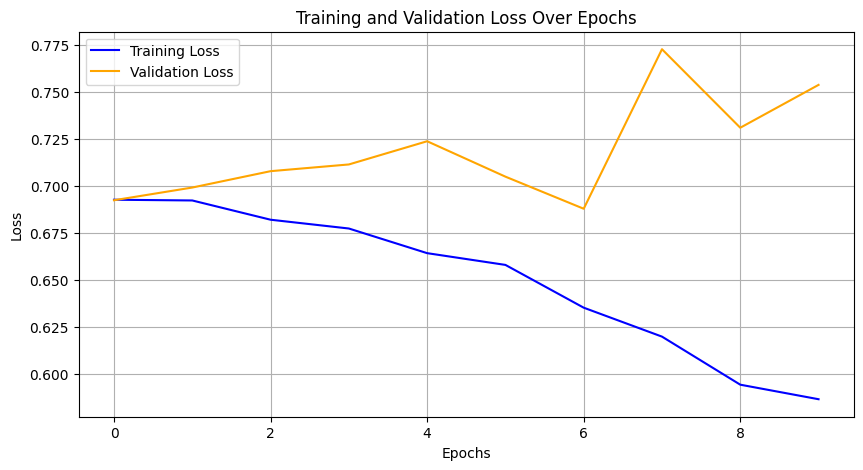

In [126]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss', color='blue')
plt.plot(valid_losses, label='Validation Loss', color='orange')
plt.title('Training and Validation Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()

In [127]:
def predict(model, tweet):
    model.eval()
    encoded_tweet = encode(tweet)
    padded_tweet = pad_sequence([encoded_tweet], batch_first=True, padding_value=vocab['<pad>'])

    with torch.no_grad():
        output = model(padded_tweet)
        _, predicted = torch.max(output, 1)
        return 'positive' if predicted.item() == 1 else 'negative'

In [128]:
predicted_label = predict(model, "python is great!!")
print(f'Predicted label: {predicted_label}')

Predicted label: positive


In [129]:
predict(model,"It is wrong")

'negative'

### LSTMClassifier Model Architecture (Mermaid Diagram)

```mermaid
graph TD
    A[Input: Token Indices<br/>(Batch, SeqLen)] --> B[Embedding Layer<br/>(Batch, SeqLen, Embedding Dim)]
    B --> C[Dropout Layer<br/>(Batch, SeqLen, Embedding Dim)]
    C --> D[LSTM Layer<br/>(Batch, SeqLen, Hidden Dim)]
    D --> E[Select Last Hidden State<br/>(Batch, Hidden Dim)]
    E --> F[Linear Layer (Fully Connected)<br/>(Batch, Num Classes)]
    F --> G[Output: Logits<br/>(Batch, Num Classes)]
```

- **Embedding Layer:** Converts input token indices to dense vectors.
- **Dropout Layer:** Regularizes the embedding output.
- **LSTM Layer:** Processes the sequence and outputs hidden states for each time step.
- **Select Last Hidden State:** Takes the last time step's hidden state for each sequence.
- **Linear Layer:** Maps the hidden state to the number of output classes.
- **Output:** Logits for each class.